# 3. Dimensionality Reduction

This notebook applies Principal Component Analysis (PCA) to the numerical feature matrix produced by notebook 02. It selects the number of components dynamically, evaluates the retained information, and persists a reduced representation for clustering.

## 3.1. Environment and Library Imports

In [2]:
# Standard library imports
import logging
import sys
from pathlib import Path

# Third-party imports
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

In [3]:
current_directory = Path.cwd().resolve()
project_candidates = (current_directory, *current_directory.parents)

PROJECT_ROOT = next(
    (path for path in project_candidates if (path / "src").is_dir()),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root directory.")

SRC_DIRECTORY = PROJECT_ROOT / "src"

if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

LOGGER = logging.getLogger("facebook_clustering.dimensionality_reduction")

### 3.1.1. Custom Utilities

In [4]:
from data_collection_utils import save_dataframe_csv
from data_preprocessing_utils import validate_numeric_matrix

## 3.2. Configuration

The variance threshold and all input and output paths are defined centrally to keep the analysis reproducible.

In [5]:
MODEL_MATRIX_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "facebook_posts_model_matrix.csv"
)
PCA_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "facebook_posts_pca.csv"
)
EXPLAINED_VARIANCE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pca_explained_variance.csv"
)
COMPONENT_WEIGHTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pca_component_weights.csv"
)
PCA_ARTIFACT_PATH = PROJECT_ROOT / "artifacts" / "pca.joblib"
FIGURES_DIRECTORY = PROJECT_ROOT / "reports" / "figures"

RECORD_ID_COLUMN = "record_id"
VARIANCE_THRESHOLD = 0.85
TOP_FEATURES_PER_COMPONENT = 5

## 3.3. Model Matrix Loading

The numerical matrix generated by notebook 02 is the only modeling input. `record_id` is preserved for alignment but excluded from PCA.

In [6]:
if not MODEL_MATRIX_PATH.exists():
    raise FileNotFoundError(
        "Model matrix not found. Run 02_data_preprocessing.ipynb first."
    )

model_matrix = pd.read_csv(MODEL_MATRIX_PATH)

if RECORD_ID_COLUMN not in model_matrix.columns:
    raise ValueError(
        f"Required identifier column not found: {RECORD_ID_COLUMN}"
    )

record_ids = model_matrix[RECORD_ID_COLUMN].copy()
model_features = validate_numeric_matrix(
    model_matrix,
    excluded_columns=[RECORD_ID_COLUMN],
)

if record_ids.duplicated().any():
    raise ValueError("Duplicated record identifiers found.")

LOGGER.info("Model matrix loaded from: %s", MODEL_MATRIX_PATH)
LOGGER.info("Observations: %d", len(model_features))
LOGGER.info("Input features: %d", model_features.shape[1])

Model matrix loaded from: C:\Projetos\facebook_clusterizacao\data\processed\facebook_posts_model_matrix.csv
Observations: 7,050
Input features: 19


## 3.4. Full PCA Diagnostic

A full PCA model is fitted first to measure the individual and cumulative explained variance of every available component. The model matrix is not standardized again because notebook 02 already applied feature-specific transformations, and PCA centers its input by default.

In [7]:
full_pca = PCA(svd_solver="full")
full_pca.fit(model_features)

explained_variance_ratio = full_pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(explained_variance_ratio) + 1),
        "explained_variance_ratio": explained_variance_ratio,
        "cumulative_variance_ratio": cumulative_variance,
    }
)

display(explained_variance)

,component,explained_variance_ratio,cumulative_variance_ratio
0,1,3.056324e-01,0.305632
1,2,9.300654e-02,0.398639
2,3,8.567107e-02,0.484310
3,4,7.013093e-02,0.554441
4,5,6.524379e-02,0.619685
5,6,6.441836e-02,0.684103
6,7,6.143891e-02,0.745542
7,8,4.873866e-02,0.794281
8,9,4.309946e-02,0.837380
9,10,4.055429e-02,0.877934


## 3.5. Component Selection

The selected dimension is the smallest number of components whose cumulative explained variance reaches the configured threshold. The value is calculated on every run rather than hardcoded from the original academic notebook.

In [8]:
selected_component_count = int(
    np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1
)
selected_variance = cumulative_variance[selected_component_count - 1]

LOGGER.info("Variance threshold: %.0f%%", VARIANCE_THRESHOLD * 100)
LOGGER.info("Selected components: %d", selected_component_count)
LOGGER.info("Preserved variance: %.2f%%", selected_variance * 100)

Variance threshold: 85%
Selected components: 10
Preserved variance: 87.79%


In [9]:
variance_thresholds = [0.80, 0.85, 0.90, 0.95]

threshold_summary = pd.DataFrame(
    {
        "variance_threshold": variance_thresholds,
        "required_components": [
            int(np.searchsorted(cumulative_variance, threshold) + 1)
            for threshold in variance_thresholds
        ],
    }
)

display(threshold_summary)

,variance_threshold,required_components
0,0.80,9
1,0.85,10
2,0.90,11
3,0.95,13


### 3.5.1. Explained Variance Visualization

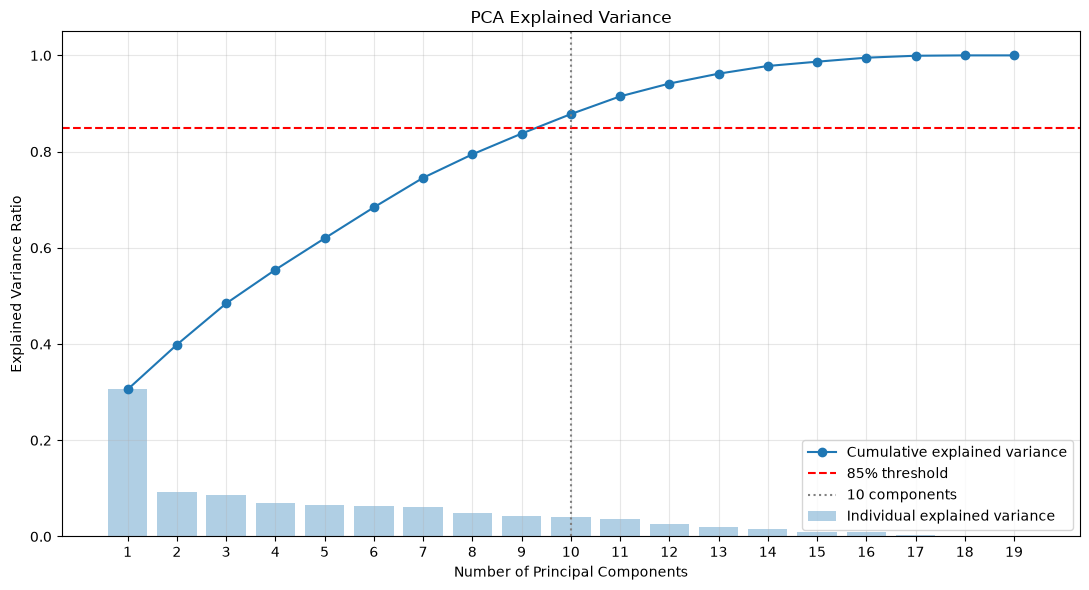

In [10]:
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(
    explained_variance["component"],
    explained_variance["explained_variance_ratio"],
    alpha=0.35,
    label="Individual explained variance",
)
ax.plot(
    explained_variance["component"],
    explained_variance["cumulative_variance_ratio"],
    marker="o",
    label="Cumulative explained variance",
)
ax.axhline(
    VARIANCE_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"{VARIANCE_THRESHOLD:.0%} threshold",
)
ax.axvline(
    selected_component_count,
    color="gray",
    linestyle=":",
    label=f"{selected_component_count} components",
)
ax.set(
    title="PCA Explained Variance",
    xlabel="Number of Principal Components",
    ylabel="Explained Variance Ratio",
)
ax.set_xticks(explained_variance["component"])
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "pca_explained_variance.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 3.6. Final PCA Model

In [11]:
pca = PCA(
    n_components=selected_component_count,
    svd_solver="full",
)
reduced_values = pca.fit_transform(model_features)

component_names = [
    f"PC{component_number}"
    for component_number in range(1, selected_component_count + 1)
]

pca_scores = pd.DataFrame(
    reduced_values,
    columns=component_names,
    index=model_features.index,
)
pca_scores.insert(0, RECORD_ID_COLUMN, record_ids.to_numpy())

display(pca_scores.head())

,record_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,0,4.519131,-0.384975,0.836266,-0.445904,0.911757,-0.530315,1.222639,-0.326319,-1.565734,0.126846
1,1,-1.104641,2.350609,0.761376,-0.744820,0.348764,-1.333139,0.184551,0.809450,-0.225122,-0.463083
2,2,2.742697,-0.370138,1.178749,-0.602454,-0.009279,-1.404994,1.223804,-1.204723,-0.346012,-0.220541
3,3,-1.101554,0.926340,1.312509,-0.778429,0.330679,-1.348653,0.429630,0.443289,-0.002169,-0.136756
4,4,-0.330849,0.701327,1.425267,-0.472239,-1.089144,1.002386,0.314485,0.096492,0.017951,-0.138206


### 3.6.1. Reduction Quality

Reconstruction error complements explained variance by measuring the average squared difference between the original matrix and its PCA reconstruction.

In [12]:
reconstructed_values = pca.inverse_transform(reduced_values)
reconstruction_mse = np.mean(
    (model_features.to_numpy() - reconstructed_values) ** 2
)

reduction_summary = pd.Series(
    {
        "original_feature_count": model_features.shape[1],
        "selected_component_count": selected_component_count,
        "preserved_variance": pca.explained_variance_ratio_.sum(),
        "reconstruction_mse": reconstruction_mse,
    },
    name="value",
)

display(reduction_summary.to_frame())

,value
original_feature_count,19.000000
selected_component_count,10.000000
preserved_variance,0.877934
reconstruction_mse,0.099694


## 3.7. Component Weights

Component weights show how strongly each transformed input feature contributes to each principal component. They should be interpreted in the transformed feature space rather than as effects in the original engagement-count scale.

In [13]:
component_weights = pd.DataFrame(
    pca.components_.T,
    index=model_features.columns,
    columns=component_names,
)
component_weights.index.name = "feature"

top_component_features = []

for component in component_names:
    top_features = (
        component_weights[component]
        .abs()
        .nlargest(TOP_FEATURES_PER_COMPONENT)
        .index
    )

    for feature in top_features:
        weight = component_weights.loc[feature, component]
        top_component_features.append(
            {
                "component": component,
                "feature": feature,
                "weight": weight,
                "absolute_weight": abs(weight),
            }
        )

top_component_features = pd.DataFrame(top_component_features)
display(top_component_features)

,component,feature,weight,absolute_weight
0,PC1,num_loves,0.419457,0.419457
1,PC1,num_shares,0.407152,0.407152
2,PC1,num_comments,0.404573,0.404573
3,PC1,num_hahas,0.370552,0.370552
4,PC1,num_wows,0.314081,0.314081
5,PC2,publication_hour_cos,0.674651,0.674651
6,PC2,publication_hour_sin,-0.645947,0.645947
7,PC2,publication_month_sin,0.230338,0.230338
8,PC2,publication_year,0.199164,0.199164
9,PC2,num_sads,-0.108334,0.108334


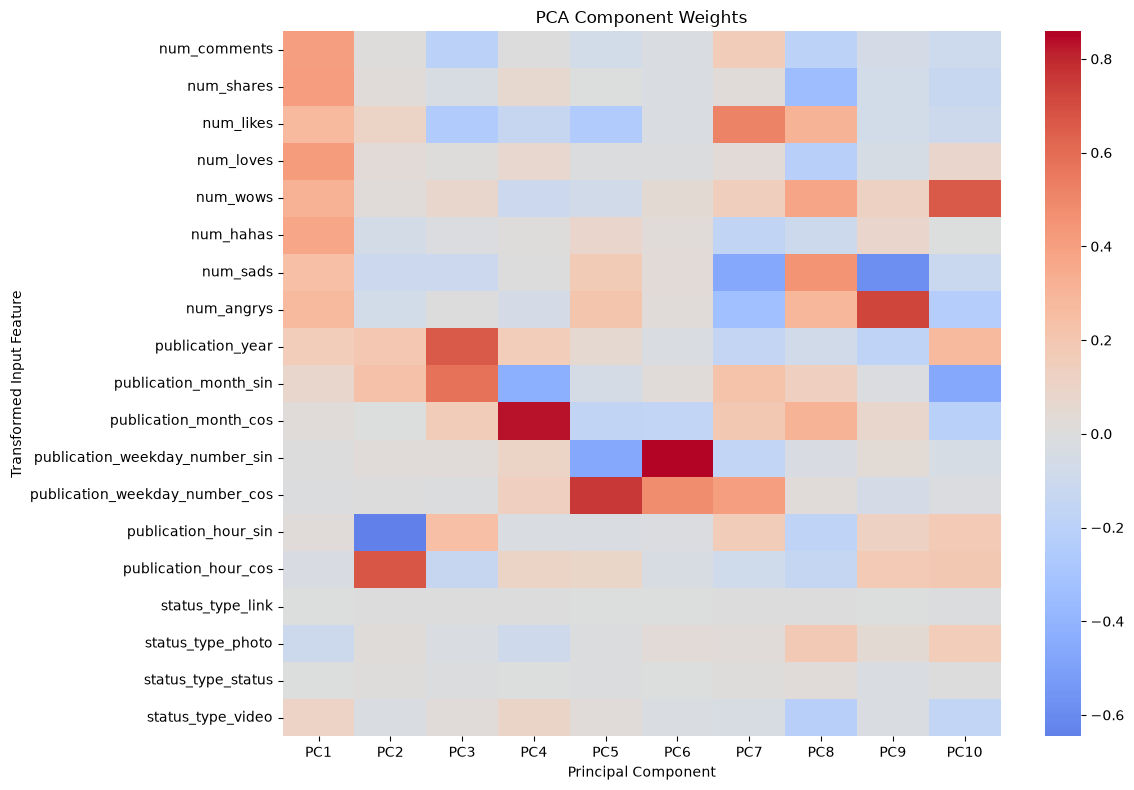

In [14]:
components_to_plot = component_names[: min(10, len(component_names))]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    component_weights[components_to_plot],
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set(
    title="PCA Component Weights",
    xlabel="Principal Component",
    ylabel="Transformed Input Feature",
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "pca_component_weights.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 3.8. Two-Dimensional Projection

The first two components provide a visual diagnostic only. Overlap in this projection does not imply that the complete selected PCA space lacks cluster structure.

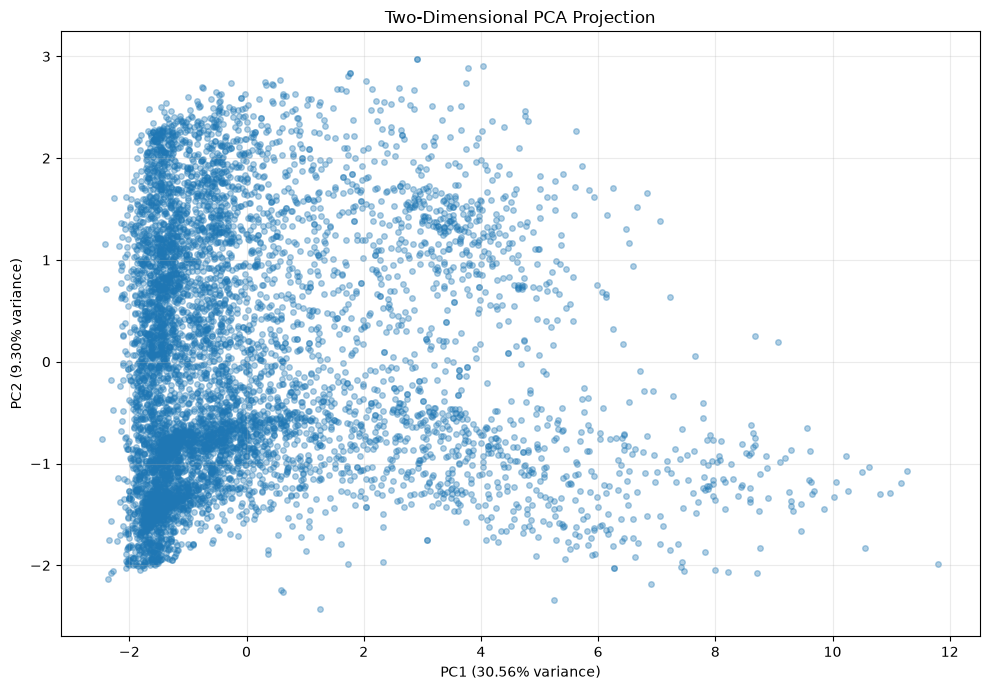

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    pca_scores["PC1"],
    pca_scores["PC2"],
    s=16,
    alpha=0.35,
)
ax.set(
    title="Two-Dimensional PCA Projection",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)",
)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "pca_projection_2d.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 3.9. Output Validation

In [16]:
component_values = validate_numeric_matrix(
    pca_scores,
    excluded_columns=[RECORD_ID_COLUMN],
    expected_row_count=len(model_matrix),
)

if not pca_scores[RECORD_ID_COLUMN].equals(record_ids):
    raise ValueError("Record identifiers are not aligned.")

if pca.explained_variance_ratio_.sum() < VARIANCE_THRESHOLD:
    raise ValueError(
        "The selected PCA model does not meet the variance threshold."
    )

if component_values.shape[1] != selected_component_count:
    raise ValueError("Unexpected number of PCA components.")

LOGGER.info("PCA output validated successfully.")
LOGGER.info("PCA output shape: %s", pca_scores.shape)

PCA output validated successfully.
Output shape: (7050, 11)


## 3.10. Artifact Persistence

In [17]:
pca_data_path = save_dataframe_csv(pca_scores, PCA_DATA_PATH)
explained_variance_path = save_dataframe_csv(
    explained_variance,
    EXPLAINED_VARIANCE_PATH,
)
component_weights_path = save_dataframe_csv(
    component_weights.reset_index(),
    COMPONENT_WEIGHTS_PATH,
)

PCA_ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pca, PCA_ARTIFACT_PATH)

LOGGER.info("PCA scores saved to: %s", pca_data_path)
LOGGER.info("Explained variance saved to: %s", explained_variance_path)
LOGGER.info("Component weights saved to: %s", component_weights_path)
LOGGER.info("PCA model saved to: %s", PCA_ARTIFACT_PATH)

PCA scores saved to: C:\Projetos\facebook_clusterizacao\data\processed\facebook_posts_pca.csv
Explained variance saved to: C:\Projetos\facebook_clusterizacao\data\processed\pca_explained_variance.csv
Component weights saved to: C:\Projetos\facebook_clusterizacao\data\processed\pca_component_weights.csv
PCA model saved to: C:\Projetos\facebook_clusterizacao\artifacts\pca.joblib


In [18]:
assert PCA_DATA_PATH.exists()
assert EXPLAINED_VARIANCE_PATH.exists()
assert COMPONENT_WEIGHTS_PATH.exists()
assert PCA_ARTIFACT_PATH.exists()

LOGGER.info("Dimensionality reduction completed successfully.")

Dimensionality reduction completed successfully.
